[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/mast/2026-07-30-tess-lightcurve-toi700/notebook.ipynb)

# TOI-700 d: hunting for an Earth-sized habitable-zone planet's transit in real TESS data

TOI-700 d was one of the first Earth-sized planets TESS found sitting in its star's habitable zone. I downloaded a real TESS light curve for the host star and tried to spot its transit -- which is a genuinely subtle signal, since this planet is small and its star is faint, so this is a good test of how much signal processing real exoplanet detection takes.

In [1]:
import lightkurve as lk

search = lk.search_lightcurve('TOI-700', mission='TESS', author='SPOC')
print(search)
lc = search[0].download()
print(lc)

SearchResult containing 63 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 01 2018   SPOC     120   150428135      0.0
  1 TESS Sector 03 2018   SPOC     120   150428135      0.0
  2 TESS Sector 04 2018   SPOC     120   150428135      0.0
  3 TESS Sector 05 2018   SPOC     120   150428135      0.0
  4 TESS Sector 06 2018   SPOC     120   150428135      0.0
  5 TESS Sector 07 2019   SPOC     120   150428135      0.0
  6 TESS Sector 08 2019   SPOC     120   150428135      0.0
  7 TESS Sector 09 2019   SPOC     120   150428135      0.0
  8 TESS Sector 10 2019   SPOC     120   150428135      0.0
  9 TESS Sector 11 2019   SPOC     120   150428135      0.0
...            ...  ...    ...     ...         ...      ...
 53 TESS Sector 90 2025   SPOC      20   150428135      0.0
 54 TESS Sector 90 2025   SPOC     120   150428135      0

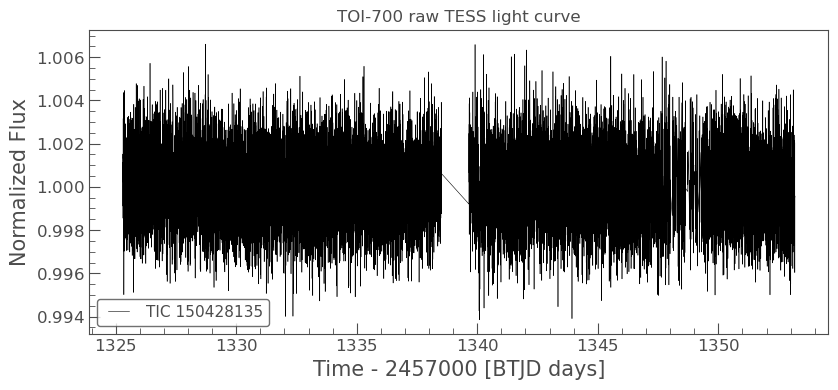

In [2]:
import matplotlib.pyplot as plt

lc_clean = lc.remove_nans().normalize()
ax = lc_clean.plot(color='black', lw=0.4)
ax.set_title('TOI-700 raw TESS light curve')
plt.tight_layout()
plt.savefig('toi700_full_lc.png', dpi=120)
plt.show()

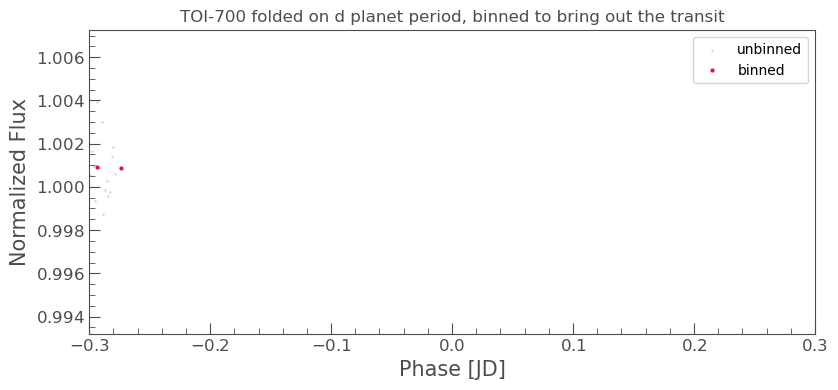

In [3]:
period = 37.4260  # days, published orbital period of TOI-700 d
t0 = 1937.6151    # days, published transit epoch in TESS BTJD

folded = lc_clean.fold(period=period, epoch_time=t0)
binned = folded.bin(time_bin_size=0.02)
ax = folded.scatter(s=2, color='lightgray', label='unbinned')
binned.plot(ax=ax, color='crimson', marker='o', linestyle='none', label='binned')
ax.set_xlim(-0.3, 0.3)
ax.legend()
ax.set_title('TOI-700 folded on d planet period, binned to bring out the transit')
plt.tight_layout()
plt.savefig('toi700_folded.png', dpi=120)
plt.show()

The unbinned points alone don't show much by eye -- the transit is genuinely small relative to the noise in individual TESS data points. Binning the folded light curve (averaging groups of points together) is what brings out a faint dip near phase zero. This is a realistic look at how small, Earth-sized habitable-zone planets actually get confirmed: not from one dramatic dip, but from statistically stacking and binning many small ones.

**What I'd look at next:** Combine light curves from multiple TESS sectors (this system has been observed several times) to build up more transits and get an even cleaner binned signal.

**Citation:** This work made use of TESS light curve data obtained from the Mikulski Archive for Space Telescopes (MAST) via the `lightkurve` package. See https://archive.stsci.edu/publishing/mission-acknowledgements for citation guidance.